In [258]:
import sys
import subprocess

# Automatically install nltk if it is missing, same idea as the teacher code.
try:
    import nltk
except ImportError:
    print('NLTK library not found. Installing it now...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk'])
    import nltk

# Importing necessary libraries
import os
import re
import time
import copy
import random
import unicodedata
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# CPU was running slowly before, so this keeps the laptop from using too many threads.
if not torch.cuda.is_available():
    torch.set_num_threads(4)

# Select computation engine (CUDA GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [259]:
# Special tokens for sequence boundaries
PAD_token = 0  # Padding token for batches
SOS_token = 1  # Start Of Sequence Token
EOS_token = 2  # End Of Sequence Token

# Main settings
# This uses all sentence pairs from the file and keeps the required 80/20 split.
data_file = 'vast_english_french.txt'
results_folder = 'Results_Problem_1'
os.makedirs(results_folder, exist_ok=True)

hidden_size = 160
learning_rate = 0.025
weight_decay = 5e-5
batch_size = 96
dropout_prob = 0.35
n_epochs = 500
max_generation_length = 77

# Long-run controls
scheduler_patience = 5
early_stop_patience = 25
min_delta = 0.0002
min_learning_rate = 0.00005

print('hidden_size:', hidden_size)
print('learning_rate:', learning_rate)
print('batch_size:', batch_size)
print('dropout:', dropout_prob)
print('epochs:', n_epochs)
print('scheduler patience:', scheduler_patience)
print('early stopping patience:', early_stop_patience)

hidden_size: 160
learning_rate: 0.025
batch_size: 96
dropout: 0.35
epochs: 500
scheduler patience: 5
early stopping patience: 25


In [260]:
def clean_text(text):
    text = unicodedata.normalize('NFC', str(text).strip().lower())
    text = ''.join(ch for ch in text if ch.isprintable())
    text = re.sub(r'([.!?,])', r'  ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def read_translation_dataset(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError('Put vast_english_french.txt in the Homework_3 folder and run again.')

    sentence_pairs = []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line == '':
                continue

            if '	' in line:
                parts = line.split('	')
            elif '|||' in line:
                parts = line.split('|||')
            else:
                parts = line.split(',', 1)

            if len(parts) >= 2:
                english = clean_text(parts[0])
                french = clean_text(parts[1])
                if english != '' and french != '':
                    sentence_pairs.append((english, french))

    return sentence_pairs


dataset = read_translation_dataset(data_file)
print('Total pairs in file:', len(dataset))
print('First pair:', dataset[0])
print('Longest English sentence length:', max(len(x[0]) for x in dataset))
print('Longest French sentence length:', max(len(x[1]) for x in dataset))

Total pairs in file: 555
First pair: ('i am cold', "j'ai froid")
Longest English sentence length: 61
Longest French sentence length: 77


In [261]:
# Train-validation split: seeded random 80/20 split.
# The seed makes the split reproducible for Problems 1, 2, and 3.
all_indices = list(range(len(dataset)))
random.Random(seed).shuffle(all_indices)
split_point = int(0.80 * len(all_indices))
train_indices = all_indices[:split_point]
val_indices = all_indices[split_point:]

train_dataset_pairs = [dataset[i] for i in train_indices]
val_dataset_pairs = [dataset[i] for i in val_indices]

print('Training pairs:', len(train_dataset_pairs))
print('Validation pairs:', len(val_dataset_pairs))

split_df = pd.DataFrame(
    [{'split': 'train', 'english': x[0], 'french': x[1]} for x in train_dataset_pairs] +
    [{'split': 'val', 'english': x[0], 'french': x[1]} for x in val_dataset_pairs]
)
split_df.to_csv(os.path.join(results_folder, 'problem1_train_val_split.csv'), index=False)
split_df.head()

Training pairs: 444
Validation pairs: 111


,split,english,french
0,train,he teaches world geography to high school classes,il enseigne la géographie mondiale à des class...
1,train,he plays bass guitar in a professional jazz band,il joue de la basse dans un groupe de jazz pro...
2,train,the weather forecast predicts heavy snow tomorrow,les prévisions météo annoncent de fortes chute...
3,train,she loves to wear long flowing cotton skirts,elle adore porter de longues jupes amples en c...
4,train,they listen to the professor with absolute att...,ils écoutent le professeur avec une attention ...


In [262]:
# Step 1: Prepare vocabulary mappings, same basic idea as the teacher code.
# This is character-level, so the model predicts one French character at a time.
unique_chars = sorted(list(set(''.join([word for pair in dataset for word in pair]))))
char_to_index = {'PAD': PAD_token, 'SOS': SOS_token, 'EOS': EOS_token}
for i, char in enumerate(unique_chars):
    char_to_index[char] = i + 3

index_to_char = {i: char for char, i in char_to_index.items()}

print('Vocabulary size:', len(char_to_index))
print('Some characters:', unique_chars[:25])

Vocabulary size: 48
Some characters: ['\x01', ' ', "'", '-', '1', '7', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r']


In [263]:
def sentence_to_indexes(sentence):
    return [char_to_index[char] for char in sentence] + [EOS_token]


def make_batches(data_pairs, batch_size=64, shuffle=True):
    # This is a simple batch maker so training is much faster than one sentence at a time.
    data_pairs = data_pairs[:]
    if shuffle:
        random.shuffle(data_pairs)

    for start in range(0, len(data_pairs), batch_size):
        batch_pairs = data_pairs[start:start + batch_size]
        input_list = [sentence_to_indexes(x[0]) for x in batch_pairs]
        target_list = [sentence_to_indexes(x[1]) for x in batch_pairs]

        max_input_len = max(len(x) for x in input_list)
        max_target_len = max(len(x) for x in target_list)

        input_lengths = torch.tensor([len(x) for x in input_list], dtype=torch.long, device=device)

        input_batch = torch.full((len(batch_pairs), max_input_len), PAD_token, dtype=torch.long)
        target_batch = torch.full((len(batch_pairs), max_target_len), PAD_token, dtype=torch.long)

        for i in range(len(batch_pairs)):
            input_batch[i, :len(input_list[i])] = torch.tensor(input_list[i], dtype=torch.long)
            target_batch[i, :len(target_list[i])] = torch.tensor(target_list[i], dtype=torch.long)

        yield input_batch.to(device), target_batch.to(device), input_lengths, batch_pairs

In [264]:
# Step 2: Define the Encoder Model
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_prob):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input_batch, input_lengths):
        embedded = self.dropout(self.embedding(input_batch))
        output, hidden_state = self.gru(embedded)

        # Important: use the hidden state from the real last character, not from PAD tokens.
        batch_numbers = torch.arange(input_batch.size(0), device=device)
        last_outputs = output[batch_numbers, input_lengths - 1]
        hidden_state = last_outputs.unsqueeze(0)
        return output, hidden_state

In [265]:
# Step 3: Define the Decoder Model
class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_prob):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)

    def forward(self, input_batch, hidden_state):
        embedded = self.dropout(self.embedding(input_batch))
        output, hidden_state = self.gru(embedded, hidden_state)
        output = self.softmax(self.out(output))
        return output, hidden_state

In [266]:
# Instantiating the models
input_size = len(char_to_index)
output_size = len(char_to_index)

encoder = Encoder(input_size=input_size, hidden_size=hidden_size, dropout_prob=dropout_prob).to(device)
decoder = Decoder(hidden_size=hidden_size, output_size=output_size, dropout_prob=dropout_prob).to(device)

# Step 4: Optimization parameters
all_model_parameters = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(all_model_parameters, lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=scheduler_patience,
    threshold=min_delta,
    min_lr=min_learning_rate
)
criterion = nn.NLLLoss(ignore_index=PAD_token)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print('Encoder parameters:', count_parameters(encoder))
print('Decoder parameters:', count_parameters(decoder))
print('Total parameters:', count_parameters(encoder) + count_parameters(decoder))

Encoder parameters: 162240
Decoder parameters: 169968
Total parameters: 332208


In [267]:
def run_one_epoch(data_pairs, training=True):
    if training:
        encoder.train()
        decoder.train()
    else:
        encoder.eval()
        decoder.eval()

    total_loss = 0.0
    total_batches = 0

    for input_batch, target_batch, input_lengths, batch_pairs in make_batches(data_pairs, batch_size=batch_size, shuffle=training):
        if training:
            optimizer.zero_grad()

        encoder_output, encoder_hidden = encoder(input_batch, input_lengths)

        # Decoder input starts with SOS, then uses the real target shifted by one character.
        sos_column = torch.full((target_batch.size(0), 1), SOS_token, dtype=torch.long, device=device)
        decoder_input = torch.cat([sos_column, target_batch[:, :-1]], dim=1)

        decoder_output, decoder_hidden = decoder(decoder_input, encoder_hidden)
        loss = criterion(decoder_output.reshape(-1, output_size), target_batch.reshape(-1))

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(all_model_parameters, 1.0)
            optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / total_batches

In [268]:
# Step 5: Core Training loop
train_losses = []
val_losses = []
lr_history = []
best_val_loss = 999999
best_epoch = 0
best_encoder_state = None
best_decoder_state = None
no_improve_count = 0
start_time = time.time()

print('Starting Training...')
for epoch in range(n_epochs):
    avg_train_loss = run_one_epoch(train_dataset_pairs, training=True)

    with torch.no_grad():
        avg_val_loss = run_one_epoch(val_dataset_pairs, training=False)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # ReduceLROnPlateau lowers the learning rate when validation loss gets stuck.
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    # Save the best validation-loss model. Early stopping uses the same validation loss.
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        best_encoder_state = copy.deepcopy(encoder.state_dict())
        best_decoder_state = copy.deepcopy(decoder.state_dict())
        no_improve_count = 0
    else:
        no_improve_count += 1

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f'Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f} | No Improve: {no_improve_count}')

    if no_improve_count >= early_stop_patience:
        print('Early stopping reached at epoch:', epoch)
        break

training_time = time.time() - start_time
actual_epochs = len(train_losses)

# Use the best validation checkpoint for the final validation metrics.
encoder.load_state_dict(best_encoder_state)
decoder.load_state_dict(best_decoder_state)

print('Training time:', round(training_time, 2), 'seconds')
print('Epochs actually run:', actual_epochs)
print('Best validation epoch:', best_epoch)
print('Best validation loss:', round(best_val_loss, 4))


Starting Training...
Epoch 000 | Train Loss: 3.0743 | Val Loss: 2.4558 | LR: 0.025000 | No Improve: 0
Epoch 010 | Train Loss: 1.4015 | Val Loss: 1.5354 | LR: 0.025000 | No Improve: 0
Epoch 020 | Train Loss: 1.0393 | Val Loss: 1.4478 | LR: 0.025000 | No Improve: 1
Epoch 030 | Train Loss: 0.8568 | Val Loss: 1.4633 | LR: 0.025000 | No Improve: 3
Epoch 040 | Train Loss: 0.6355 | Val Loss: 1.4123 | LR: 0.006250 | No Improve: 0
Epoch 050 | Train Loss: 0.5153 | Val Loss: 1.4240 | LR: 0.003125 | No Improve: 6
Epoch 060 | Train Loss: 0.4640 | Val Loss: 1.4264 | LR: 0.001563 | No Improve: 16
Early stopping reached at epoch: 69
Training time: 61.77 seconds
Epochs actually run: 70
Best validation epoch: 44
Best validation loss: 1.4115


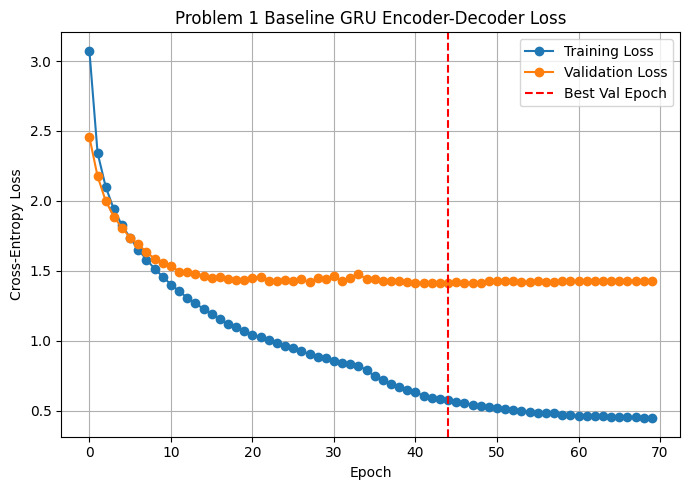

In [269]:
# Evaluation curves required by the homework
plt.figure(figsize=(7, 5))
plt.plot(train_losses, marker='o', label='Training Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')
plt.axvline(best_epoch, color='red', linestyle='--', label='Best Val Epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Problem 1 Baseline GRU Encoder-Decoder Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem1_loss_curve.png'), dpi=200, bbox_inches='tight')
plt.show()

In [270]:
def predict_sentence(input_string):
    encoder.eval()
    decoder.eval()

    input_indexes = sentence_to_indexes(clean_text(input_string))
    input_tensor = torch.tensor(input_indexes, dtype=torch.long, device=device).unsqueeze(0)
    input_lengths = torch.tensor([len(input_indexes)], dtype=torch.long, device=device)

    with torch.no_grad():
        encoder_output, encoder_hidden = encoder(input_tensor, input_lengths)
        decoder_hidden = encoder_hidden
        decoder_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)
        predicted_indices = []

        for di in range(max_generation_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output[:, -1, :].topk(1)
            idx_pred = topi.item()

            if idx_pred == EOS_token:
                break

            if idx_pred not in (PAD_token, SOS_token):
                predicted_indices.append(idx_pred)

            decoder_input = torch.tensor([[idx_pred]], dtype=torch.long, device=device)

    predicted_string = ''.join([index_to_char[idx] for idx in predicted_indices])
    return predicted_string


def character_accuracy(target_string, predicted_string):
    if len(target_string) == 0 and len(predicted_string) == 0:
        return 1.0

    max_len = max(len(target_string), len(predicted_string))
    correct_chars = 0
    for i in range(max_len):
        if i < len(target_string) and i < len(predicted_string):
            if target_string[i] == predicted_string[i]:
                correct_chars += 1
    return correct_chars / max_len

In [271]:
# Step 6: Evaluation: exact sentence accuracy and BLEU-4
encoder.eval()
decoder.eval()

correct_exact_matches = 0
total_char_bleu_score = 0.0
total_word_bleu_score = 0.0
total_char_accuracy = 0.0
chencherry = SmoothingFunction()
rows = []

print('--- Generating Evaluation Examples ---')
for i, (input_string, target_string) in enumerate(val_dataset_pairs):
    predicted_string = predict_sentence(input_string)

    if predicted_string == target_string:
        correct_exact_matches += 1

    # Character-level BLEU matches the style of the teacher sequence2sequence.py code.
    char_bleu = sentence_bleu([list(target_string)], list(predicted_string), smoothing_function=chencherry.method1)

    # Word BLEU is also saved because the homework is sentence translation.
    word_bleu = sentence_bleu([target_string.split()], predicted_string.split(), smoothing_function=chencherry.method1)

    char_acc = character_accuracy(target_string, predicted_string)

    total_char_bleu_score += char_bleu
    total_word_bleu_score += word_bleu
    total_char_accuracy += char_acc

    match_status = 'PASS' if predicted_string == target_string else 'FAIL'
    rows.append({
        'input_english': input_string,
        'target_french': target_string,
        'predicted_french': predicted_string,
        'exact_match': match_status,
        'char_accuracy': char_acc,
        'char_bleu4': char_bleu,
        'word_bleu4': word_bleu
    })

    if i < 5:
        print(f'Input: {input_string:<38} | Target: {target_string:<38} | Predicted: {predicted_string:<38} | Match: {match_status:<4} | Char BLEU: {char_bleu:.4f}')

final_exact_accuracy = correct_exact_matches / len(val_dataset_pairs)
average_char_bleu = total_char_bleu_score / len(val_dataset_pairs)
average_word_bleu = total_word_bleu_score / len(val_dataset_pairs)
average_char_accuracy = total_char_accuracy / len(val_dataset_pairs)

print('--------------------------------------------------------------------------------')
print('Final Global Metrics across Validation Set:')
print(f' -> Traditional Exact-Match Accuracy : {final_exact_accuracy * 100:.2f}% ({correct_exact_matches}/{len(val_dataset_pairs)} samples)')
print(f' -> Average Character Accuracy       : {average_char_accuracy * 100:.2f}%')
print(f' -> Average Character BLEU-4 Score   : {average_char_bleu:.4f}')
print(f' -> Average Word BLEU-4 Score        : {average_word_bleu:.4f}')

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(results_folder, 'problem1_validation_results.csv'), index=False)
results_df.head()

--- Generating Evaluation Examples ---
Input: they feed the pigeons in the square    | Target: ils nourrissent les pigeons sur la place | Predicted: ils vont à la porte a une tournoi prochaine | Match: FAIL | Char BLEU: 0.2355
Input: she practices yoga every morning       | Target: elle pratique le yoga tous les matins  | Predicted: elle a perdu matin est très compétitif | Match: FAIL | Char BLEU: 0.2991
Input: i enjoy walking in the snow            | Target: j'aime marcher dans la neige           | Predicted: j'ai fermement le couramment           | Match: FAIL | Char BLEU: 0.1545
Input: she loves to wear modern jackets       | Target: elle adore porter des vestes modernes  | Predicted: elle a perdu ses clés de collection des recherches un cousilles comme de la m | Match: FAIL | Char BLEU: 0.1701
Input: the city bus arrives precisely at five o'clock | Target: le bus de la ville arrive précisément à cinq heures | Predicted: le chien attrape la biologique         | Match: FAIL | Char BL

,input_english,target_french,predicted_french,exact_match,char_accuracy,char_bleu4,word_bleu4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,ils vont à la porte a une tournoi prochaine,FAIL,0.139535,0.235525,0.028518
1,she practices yoga every morning,elle pratique le yoga tous les matins,elle a perdu matin est très compétitif,FAIL,0.210526,0.299083,0.033032
2,i enjoy walking in the snow,j'aime marcher dans la neige,j'ai fermement le couramment,FAIL,0.178571,0.154501,0.000000
3,she loves to wear modern jackets,elle adore porter des vestes modernes,elle a perdu ses clés de collection des recher...,FAIL,0.129870,0.170115,0.015719
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive précisément à cinq h...,le chien attrape la biologique,FAIL,0.058824,0.116611,0.023505


In [272]:
# Teacher-style training-set check
# The teacher sequence2sequence.py evaluates on the same dataloader used for training.
# This is not the main homework metric, but it helps compare with the teacher example output.
train_correct = 0
train_char_bleu_total = 0.0
train_char_acc_total = 0.0

for input_string, target_string in train_dataset_pairs:
    predicted_string = predict_sentence(input_string)

    if predicted_string == target_string:
        train_correct += 1

    train_char_bleu_total += sentence_bleu([list(target_string)], list(predicted_string), smoothing_function=SmoothingFunction().method1)
    train_char_acc_total += character_accuracy(target_string, predicted_string)

teacher_style_train_accuracy = train_correct / len(train_dataset_pairs)
teacher_style_train_bleu = train_char_bleu_total / len(train_dataset_pairs)
teacher_style_train_char_accuracy = train_char_acc_total / len(train_dataset_pairs)

print('Teacher-style Training Exact Accuracy:', round(teacher_style_train_accuracy * 100, 2), '%')
print('Teacher-style Training Character Accuracy:', round(teacher_style_train_char_accuracy * 100, 2), '%')
print('Teacher-style Training BLEU-4:', round(teacher_style_train_bleu, 4))

Teacher-style Training Exact Accuracy: 0.45 %
Teacher-style Training Character Accuracy: 18.82 %
Teacher-style Training BLEU-4: 0.2088


In [273]:
# Save a small summary table for the report
summary_df = pd.DataFrame([{
    'model': 'Baseline GRU Encoder-Decoder',
    'direction': 'English to French',
    'seed': seed,
    'train_size': len(train_dataset_pairs),
    'validation_size': len(val_dataset_pairs),
    'hidden_size': hidden_size,
    'dropout_prob': dropout_prob,
    'starting_learning_rate': learning_rate,
    'final_learning_rate': optimizer.param_groups[0]['lr'],
    'weight_decay': weight_decay,
    'batch_size': batch_size,
    'max_epochs': n_epochs,
    'epochs_run': actual_epochs,
    'scheduler_patience': scheduler_patience,
    'early_stop_patience': early_stop_patience,
    'best_epoch': best_epoch,
    'final_train_loss': train_losses[-1],
    'final_validation_loss': val_losses[-1],
    'best_validation_loss': best_val_loss,
    'traditional_sequence_accuracy': final_exact_accuracy,
    'validation_character_accuracy': average_char_accuracy,
    'validation_bleu4_char_level': average_char_bleu,
    'validation_bleu4_word_level': average_word_bleu,
    'teacher_style_train_accuracy': teacher_style_train_accuracy,
    'teacher_style_train_char_accuracy': teacher_style_train_char_accuracy,
    'teacher_style_train_bleu4': teacher_style_train_bleu,
    'training_time_sec': training_time,
    'encoder_params': count_parameters(encoder),
    'decoder_params': count_parameters(decoder),
    'total_params': count_parameters(encoder) + count_parameters(decoder),
    'hardware': str(device)
}])

summary_df.to_csv(os.path.join(results_folder, 'problem1_summary.csv'), index=False)
summary_df

,model,direction,seed,train_size,validation_size,hidden_size,dropout_prob,starting_learning_rate,final_learning_rate,weight_decay,...,validation_bleu4_char_level,validation_bleu4_word_level,teacher_style_train_accuracy,teacher_style_train_char_accuracy,teacher_style_train_bleu4,training_time_sec,encoder_params,decoder_params,total_params,hardware
0,Baseline GRU Encoder-Decoder,English to French,42,444,111,160,0.35,0.025,0.000391,0.00005,...,0.188116,0.050088,0.004505,0.188151,0.20877,61.77148,162240,169968,332208,cpu


In [274]:
# Save just the 5 qualitative examples for the report
sample_df = results_df.head(5)
sample_df.to_csv(os.path.join(results_folder, 'problem1_sample_translations.csv'), index=False)
sample_df

,input_english,target_french,predicted_french,exact_match,char_accuracy,char_bleu4,word_bleu4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,ils vont à la porte a une tournoi prochaine,FAIL,0.139535,0.235525,0.028518
1,she practices yoga every morning,elle pratique le yoga tous les matins,elle a perdu matin est très compétitif,FAIL,0.210526,0.299083,0.033032
2,i enjoy walking in the snow,j'aime marcher dans la neige,j'ai fermement le couramment,FAIL,0.178571,0.154501,0.000000
3,she loves to wear modern jackets,elle adore porter des vestes modernes,elle a perdu ses clés de collection des recher...,FAIL,0.129870,0.170115,0.015719
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive précisément à cinq h...,le chien attrape la biologique,FAIL,0.058824,0.116611,0.023505
